In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime

In [46]:
omi_mls_mean_ds = xr.open_dataarray("/glade/u/home/mvoncyga/SOARS_2025/data/OMI_MLS_climatology_files/OMIMLS_300hpa_monthly_mean_2005_2024.nc")
omi_mls_stdev_ds = xr.open_dataarray("/glade/u/home/mvoncyga/SOARS_2025/data/OMI_MLS_climatology_files/OMIMLS_300hpa_monthly_stdev_2005_2024.nc")

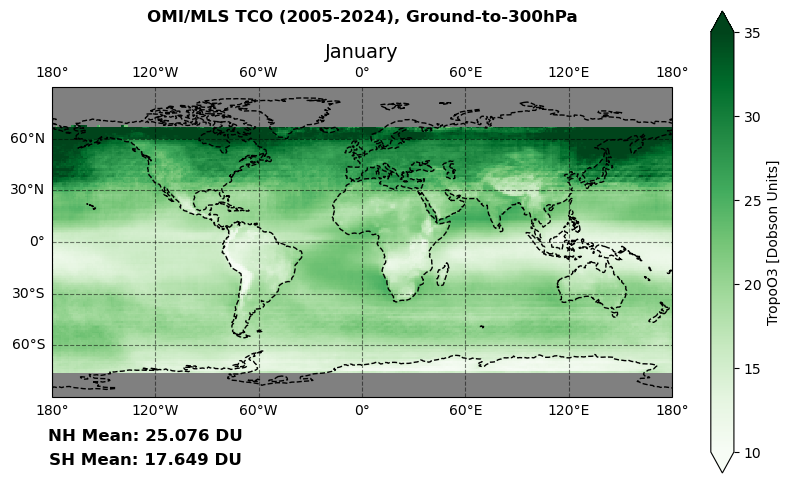

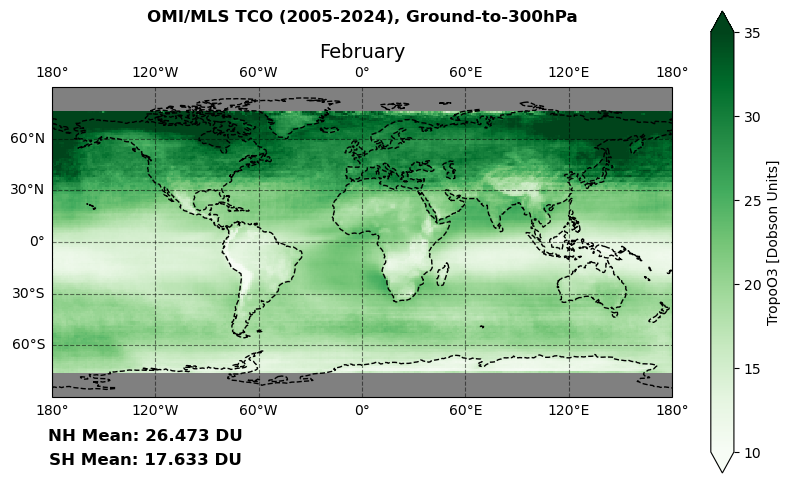

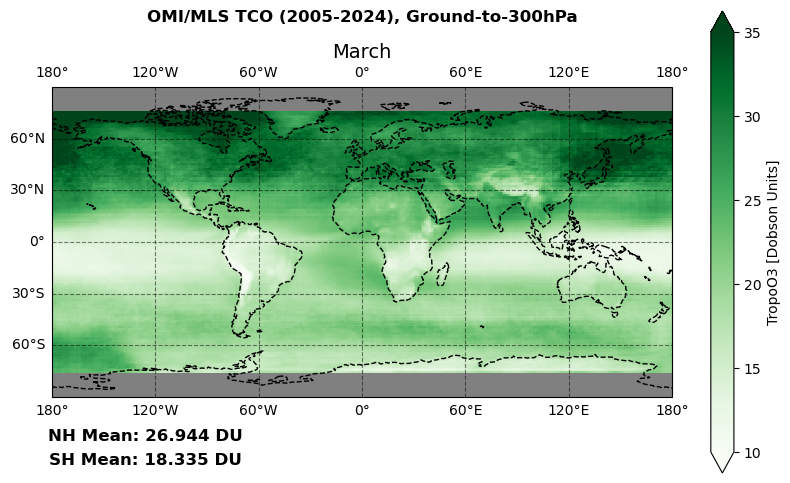

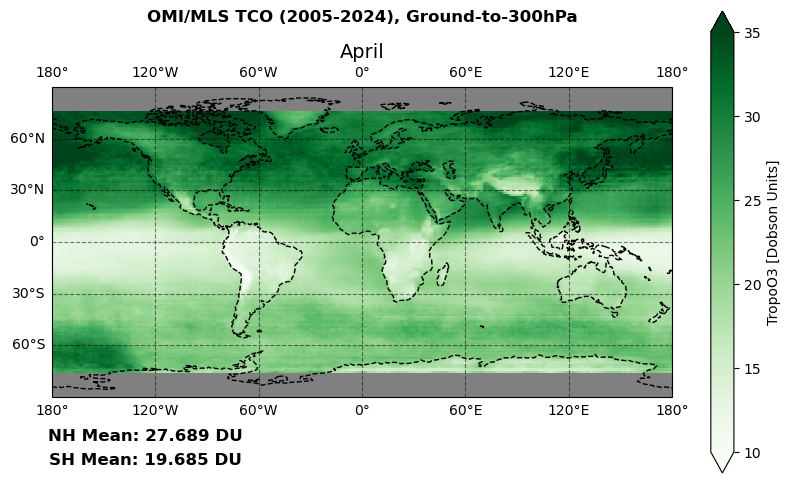

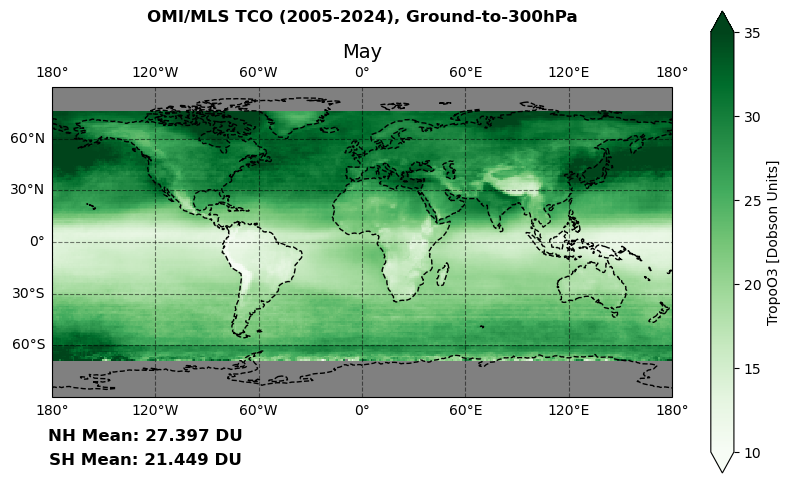

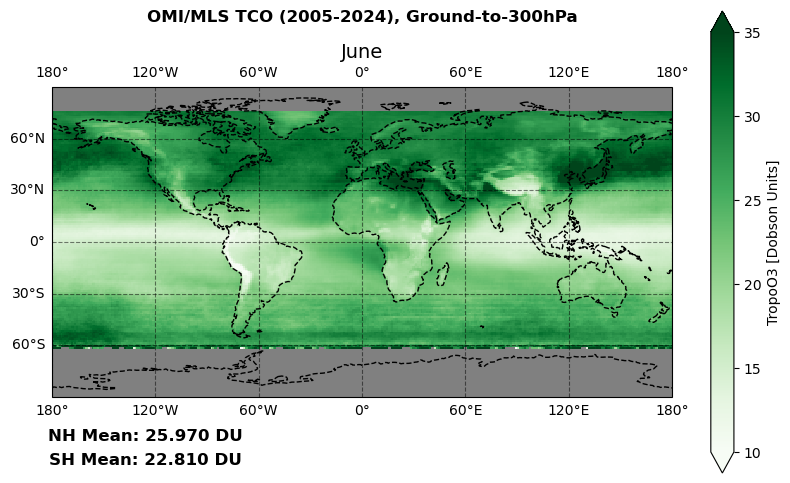

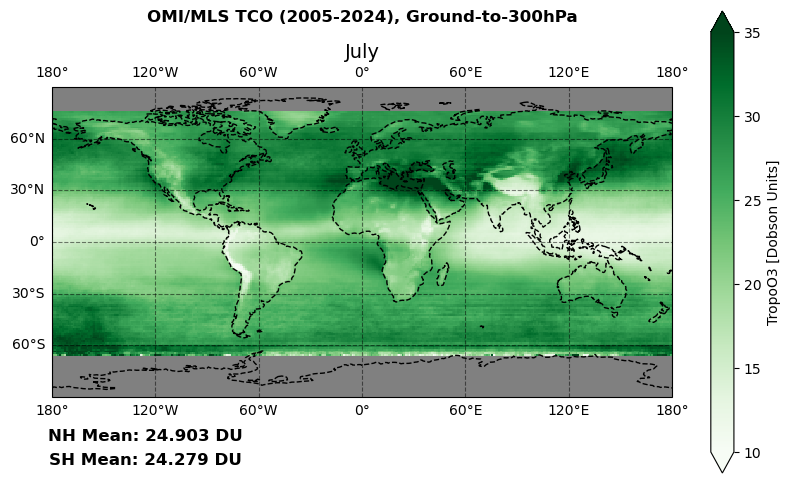

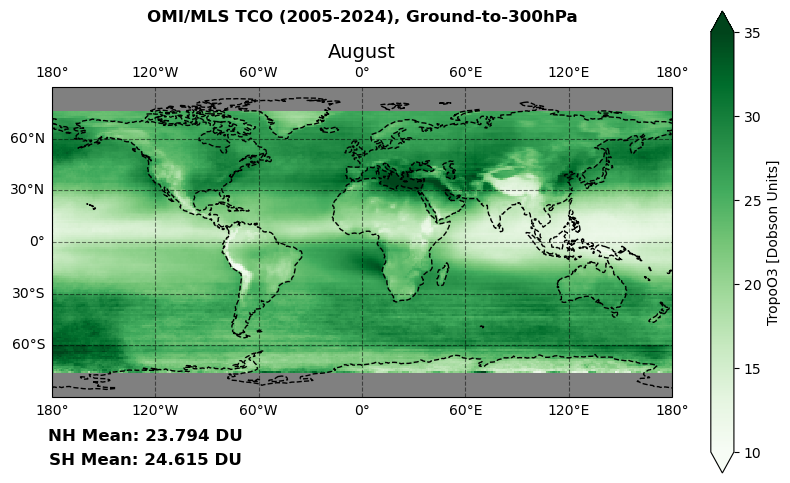

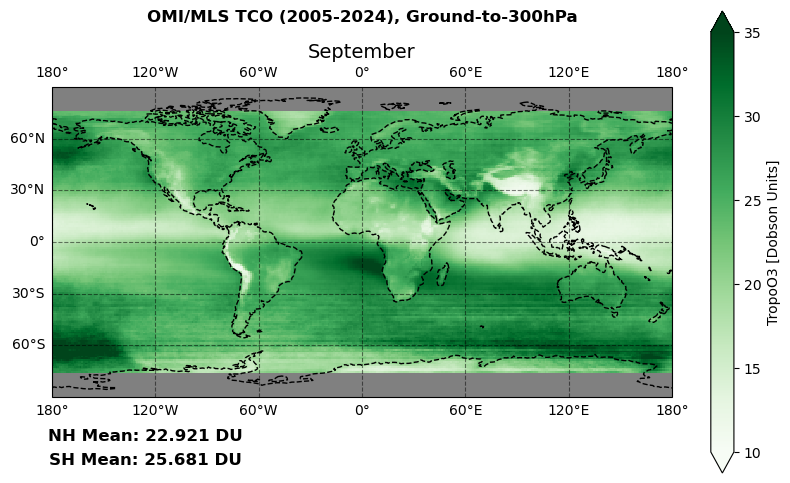

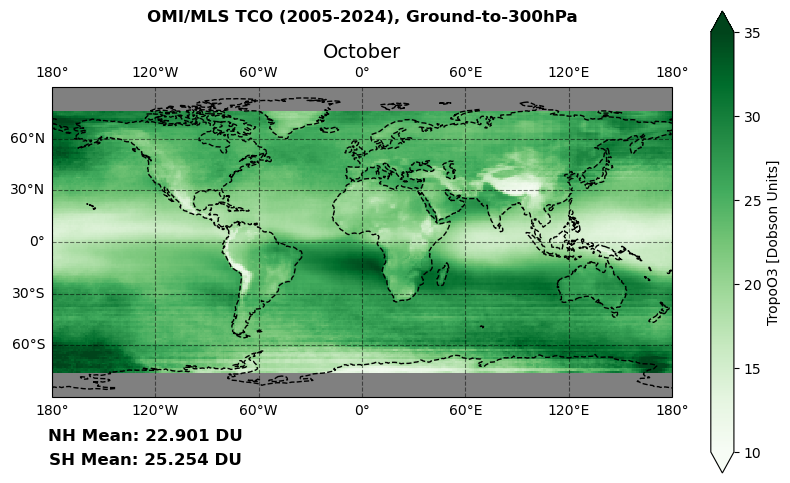

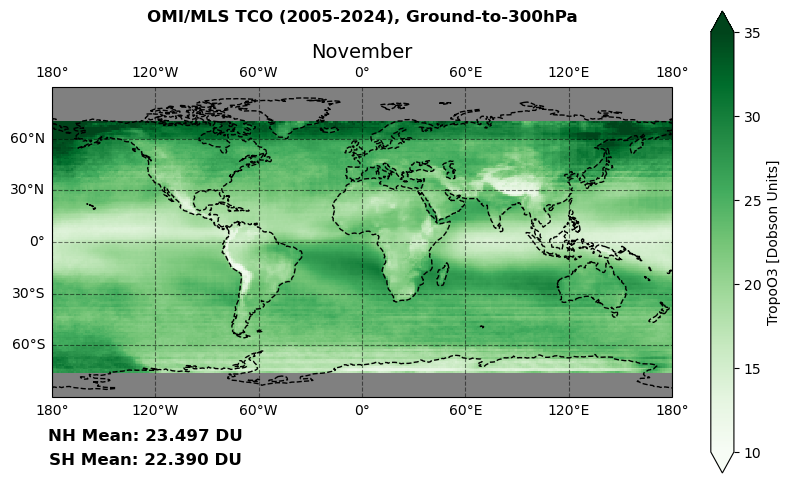

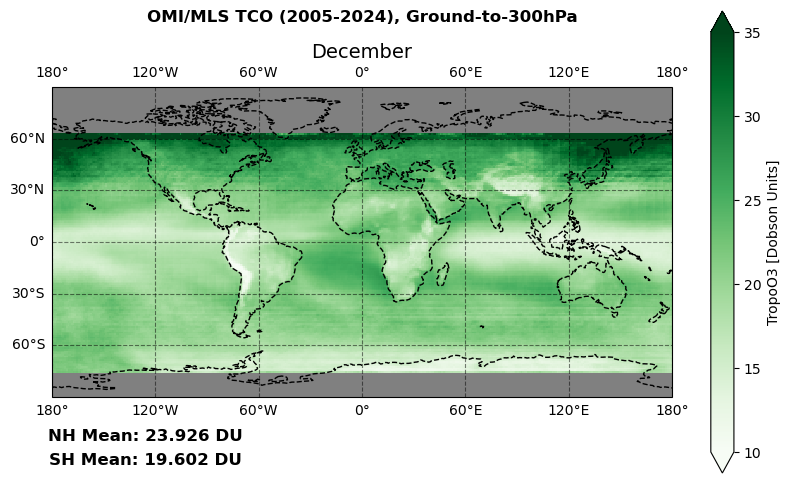

In [79]:
# plot the monthly means

month_list = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
alphabet = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l'] # for cycling through figures to create a gif

i=0

for month in month_list:
    plt.figure(figsize=(10, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_facecolor('gray')
    omi_mls_mean_ds[i].plot(ax=ax,transform=ccrs.PlateCarree(central_longitude=0), 
                         x='longitude', y='latitude', vmin=10, vmax=35, extend='both', cmap='Greens')
    ax.add_feature(cfeature.COASTLINE, linestyle='--')
    ax.set_global()

    # adding gridlines
    gl = ax.gridlines(draw_labels=True, color='black', alpha=0.5, linestyle='--')
    gl.right_labels = False

    ax.set_title(str(month), fontsize=14)
    formatted_mean = f"{omi_mls_mean_ds[i].mean().data:.3f}"

    #ax.text(0.10, -0.15, 'Mean: ' + str(formatted_mean) + ' DU', va='bottom', ha='center',
    #        rotation='horizontal', rotation_mode='anchor',
    #       transform=ax.transAxes, fontsize=12, fontweight='bold')

    nh_formatted_mean = f"{omi_mls_mean_ds[i].sel(latitude=slice(0,90)).mean(dim={'latitude','longitude'}, skipna=True).data:.3f}"
    ax.text(0.15, -0.15, 'NH Mean: ' + str(nh_formatted_mean) + ' DU', 
            va='bottom', ha='center',
            rotation='horizontal', rotation_mode='anchor',
            transform=ax.transAxes, fontsize=12, fontweight='bold')
    
    sh_formatted_mean = f"{omi_mls_mean_ds[i].sel(latitude=slice(-90,0)).mean(dim={'latitude','longitude'}, skipna=True).data:.3f}"
    ax.text(0.15, -0.23, 'SH Mean: ' + str(sh_formatted_mean) + ' DU', 
            va='bottom', ha='center',
            rotation='horizontal', rotation_mode='anchor',
            transform=ax.transAxes, fontsize=12, fontweight='bold')

    ax.text(0.5, 1.2, 'OMI/MLS TCO (2005-2024), Ground-to-300hPa', va='bottom', ha='center',
            transform=ax.transAxes, rotation='horizontal', fontsize=12, fontweight='bold')

    plt.savefig("/glade/u/home/mvoncyga/SOARS_2025/figures/climatology_omi_mls/monthly_mean_pngs_300hpa/Monthly_Mean_TropoO3-" + str(alphabet[i]))
    plt.show()
    i+=1

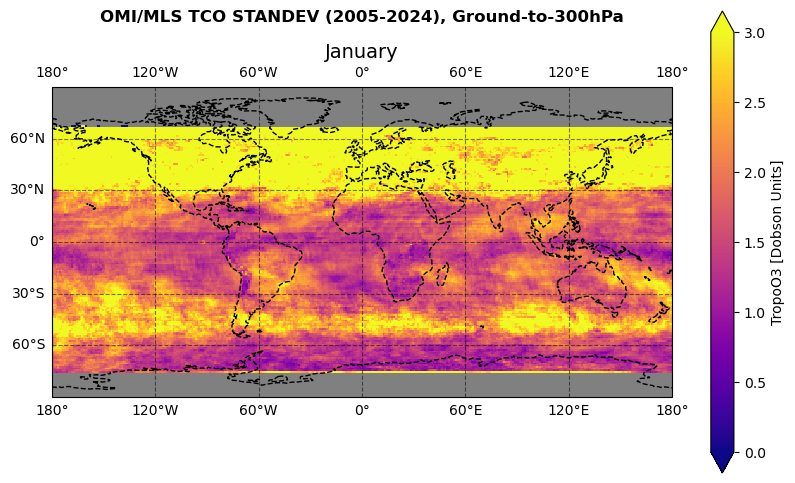

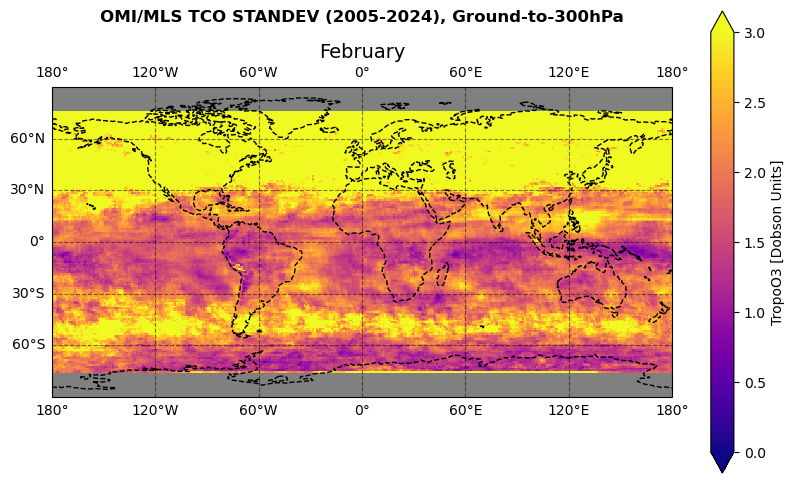

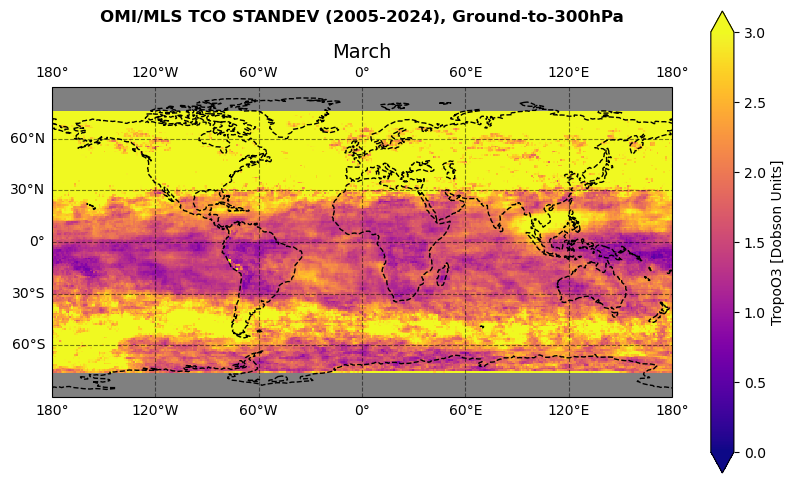

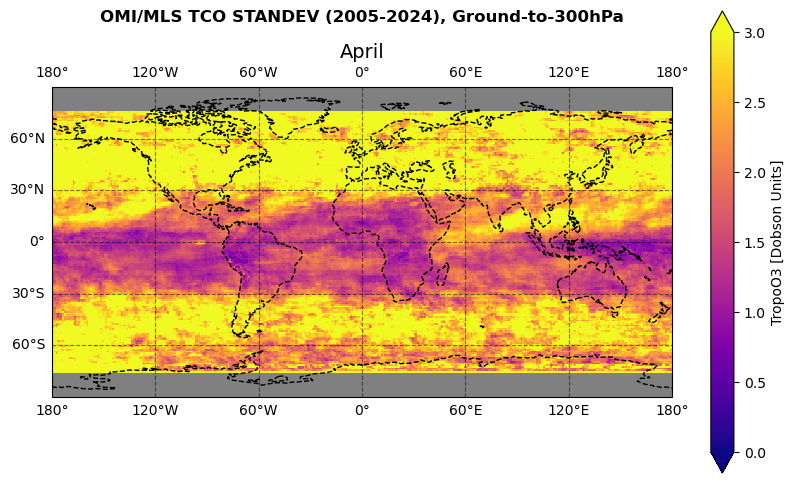

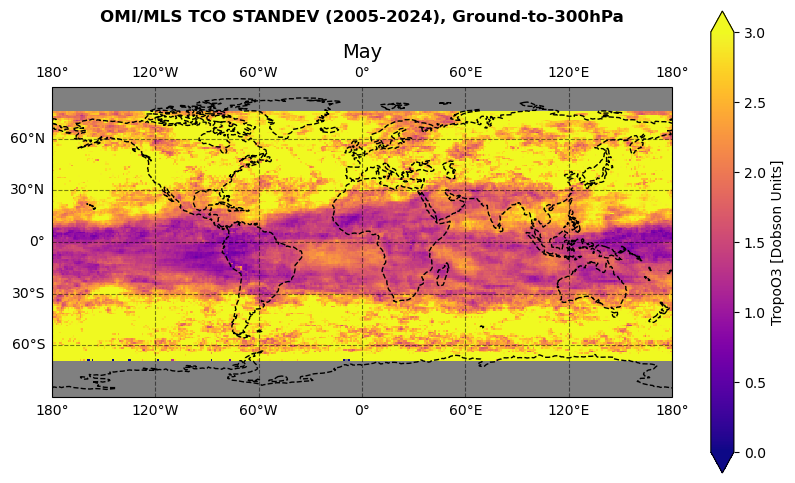

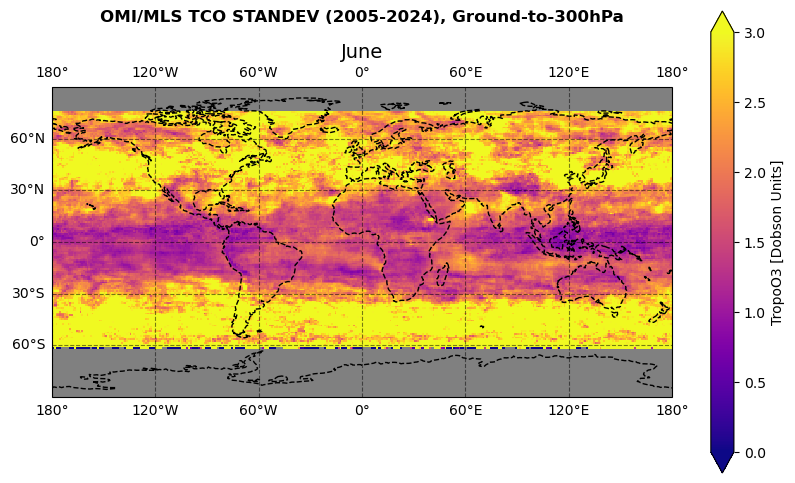

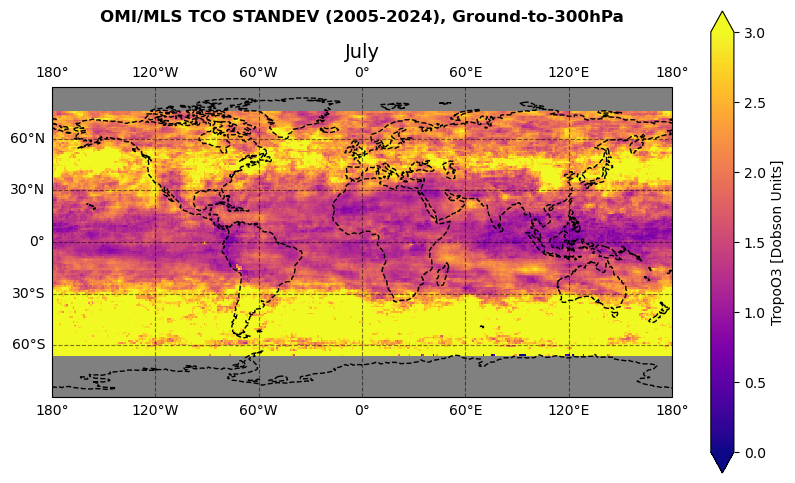

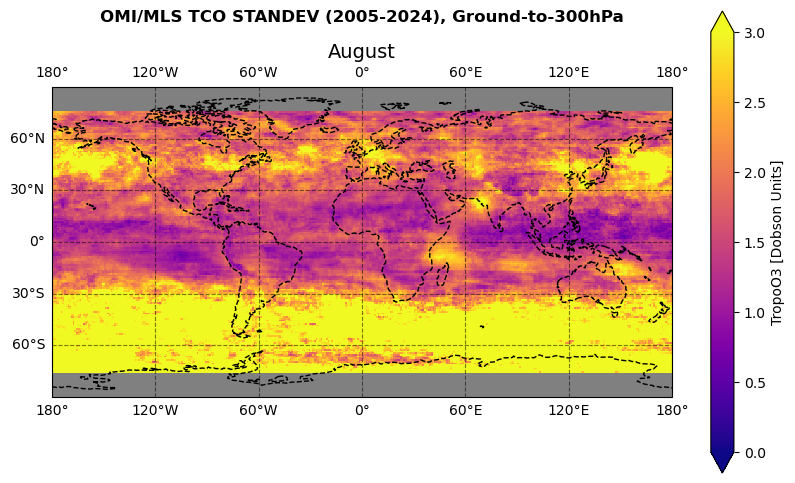

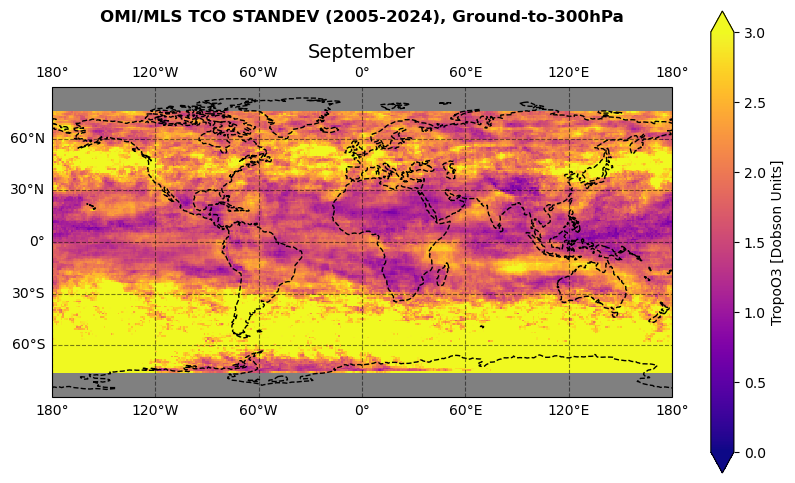

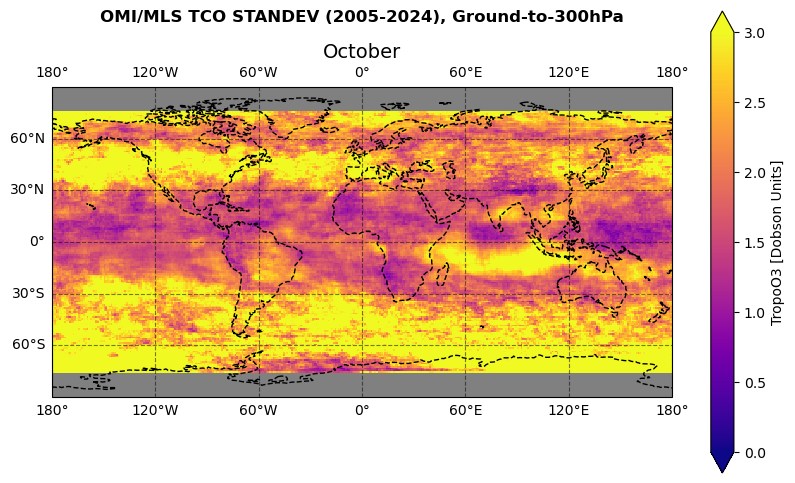

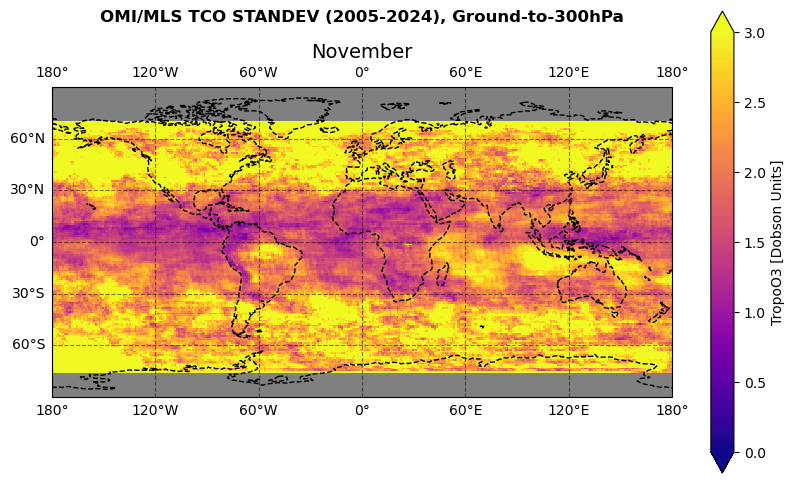

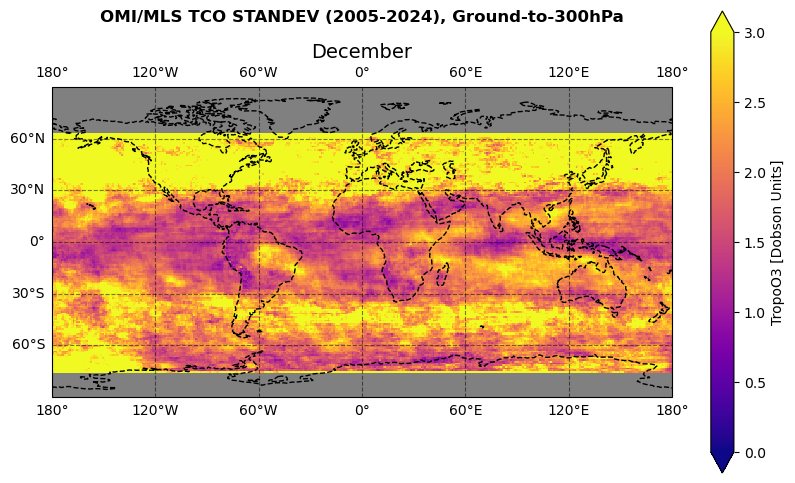

In [56]:
# plot the monthly standev

i=0
for month in month_list:
    plt.figure(figsize=(10, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_facecolor('gray')
    omi_mls_stdev_ds[i].plot(ax=ax,transform=ccrs.PlateCarree(central_longitude=0), 
                         x='longitude', y='latitude', vmin=0, vmax=3, extend='both', cmap='plasma')
    ax.add_feature(cfeature.COASTLINE, linestyle='--')
    ax.set_global()

    # adding gridlines
    gl = ax.gridlines(draw_labels=True, color='black', alpha=0.5, linestyle='--')
    gl.right_labels = False

    ax.text(0.5, 1.2, 'OMI/MLS TCO STANDEV (2005-2024), Ground-to-300hPa', va='bottom', ha='center',
            transform=ax.transAxes, rotation='horizontal', fontsize=12, fontweight='bold')
    ax.set_title(str(month), fontsize=14)

    plt.savefig("/glade/u/home/mvoncyga/SOARS_2025/figures/climatology_omi_mls/monthly_stdev_pngs_300hpa/Monthly_Standev_TropoO3-" + str(alphabet[i]))
    plt.show()
    i+=1

In [80]:
import imageio
import os

def create_gif(image_folder, output_gif, duration, file_name_locator):
    filenames = sorted([f for f in os.listdir(image_folder) if os.path.isfile(os.path.join(image_folder, f))])
    images = []
    for filename in filenames:
        if filename.startswith(file_name_locator):
            image_path = os.path.join(image_folder, filename)
            images.append(imageio.imread(image_path))
    imageio.mimsave(output_gif, images, duration=duration)

image_dir_mean = '/glade/u/home/mvoncyga/SOARS_2025/figures/climatology_omi_mls/monthly_mean_pngs_300hpa'
image_dir_stdev = '/glade/u/home/mvoncyga/SOARS_2025/figures/climatology_omi_mls/monthly_stdev_pngs_300hpa'

create_gif(image_dir_mean, "TropoO3climatology_Mean.gif", 1000, "Monthly_Mean")
#reate_gif(image_dir_stdev, "TropoO3climatology_Standev.gif", 1000, "Monthly_Standev")

/glade/derecho/scratch/mvoncyga/tmp/ipykernel_106618/4152938226.py:10: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(image_path))
